# ⏩ 使用 GitHub 模型的顺序代理工作流（Python）

## 📋 高级顺序处理教程

本笔记本演示了使用 Microsoft Agent Framework 的 **顺序工作流模式**。您将学习如何构建复杂的多步骤处理管道，其中代理按特定顺序执行，在各阶段之间传递数据和上下文。

## 🎯 学习目标

### 🔄 **顺序处理模式**
- **线性工作流设计**：创建逐步处理管道
- **数据流管理**：在顺序代理之间传递信息
- **阶段门控处理**：实现检查点和验证阶段
- **进度跟踪**：监控工作流执行和中间结果

### 🏗️ **企业管道架构**
- **业务流程建模**：将实际业务流程映射到代理工作流
- **质量保证**：多阶段验证和审查流程
- **文档处理**：顺序文档分析和转换
- **内容制作**：带有审查和批准阶段的编辑工作流

### 📊 **高级工作流功能**
- **上下文保留**：在工作流各阶段维护状态
- **错误传播**：处理顺序处理中的失败
- **性能优化**：高效的顺序执行模式
- **审计跟踪**：顺序操作的完整跟踪

## ⚙️ 先决条件和设置

### 📦 **依赖项**
```bash
pip install agent-framework-core -U
```

### 🔑 **配置**
```env
GITHUB_TOKEN=your_github_personal_access_token
GITHUB_ENDPOINT=https://models.inference.ai.azure.com
GITHUB_MODEL_ID=gpt-4o-mini
```

## 🏢 **企业顺序工作流用例**

### 📝 **文档处理管道**
```
原始文档 → 内容提取 → 分析 → 验证 → 最终输出
```

### 🔍 **质量保证工作流** 
```
初步审查 → 技术验证 → 合规检查 → 最终批准
```

### 📰 **内容制作管道**
```
研究 → 写作 → 编辑 → 审查 → 发布
```

### 💼 **业务流程自动化**
```
数据收集 → 处理 → 分析 → 报告生成 → 分发
```

## 🎨 **顺序工作流设计原则**

- **🔗 线性进展**：每个阶段依赖于前一阶段的输出
- **📋 状态管理**：在所有阶段保留上下文和数据
- **🛡️ 错误处理**：在任何阶段的优雅故障管理
- **📊 进度监控**：跟踪每个阶段的完成情况和性能
- **🔄 阶段可重用性**：设计可重用的工作流组件

让我们构建复杂的顺序处理工作流！🚀

In [ ]:
#! pip install agent-framework-core -U

In [21]:
from agent_framework.openai import OpenAIChatClient
from agent_framework import ChatMessage,WorkflowBuilder,WorkflowViz, WorkflowEvent,Role, DataContent, TextContent

ImportError: cannot import name 'DataContent' from 'agent_framework' (/home/dsa/workspace/ai-agents-for-beginners/venv/lib/python3.12/site-packages/agent_framework/__init__.py)

In [5]:

import os
import base64
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [7]:
import dotenv
dotenv.load_dotenv()
chat_client = OpenAIChatClient(
    base_url=os.getenv('API_URL'),
    api_key=os.getenv('API_KEY'),
    model_id=os.getenv('MODEL_FREE_8B')
)


In [8]:
SalesAgentName = 'Sales-Agent'
SalesAgentInstructions = 'You are my furniture sales consultant, you can find different furniture elements from the pictures and give me a purchase suggestion'

In [15]:
PriceAgentName = 'Price-Agent'
PriceAgentInstructions = '''You are a furniture pricing specialist and budget consultant. Your responsibilities include:
        1. Analyze furniture items and provide realistic price ranges based on quality, brand, and market standards
        2. Break down pricing by individual furniture pieces
        3. Provide budget-friendly alternatives and premium options
        4. Consider different price tiers (budget, mid-range, premium)
        5. Include estimated total costs for room setups
        6. Suggest where to find the best deals and shopping recommendations
        7. Factor in additional costs like delivery, assembly, and accessories
        8. Provide seasonal pricing insights and best times to buy
        Always format your response with clear price breakdowns and explanations for the pricing rationale.'''

In [10]:
QuoteAgentName = 'Quote-Agent'
QuoteAgentInstructions = '''You are a assistant that create a quote for furniture purchase.
        1. Create a well-structured quote document that includes:
        2. A title page with the document title, date, and client name
        3. An introduction summarizing the purpose of the document
        4. A summary section with total estimated costs and recommendations
        5. Use clear headings, bullet points, and tables for easy readability
        6. All quotes are presented in markdown form'''

In [18]:
sales_agent   = chat_client.as_agent(
        instructions=(
           SalesAgentInstructions
        ),
        name=SalesAgentName,
    )

price_agent = chat_client.as_agent(
        instructions=(
            PriceAgentInstructions
        ),
        name=PriceAgentName,
    )

quote_agent = chat_client.as_agent(
        instructions=(
            QuoteAgentInstructions
        ),
        name=QuoteAgentName,
    )


In [19]:
workflow = WorkflowBuilder().set_start_executor(sales_agent).add_edge(sales_agent, price_agent).add_edge(price_agent, quote_agent).build()

In [22]:
print('生成工作流可视化...')
viz = WorkflowViz(workflow)
# 打印出 mermaid 字符串。
print('Mermaid 字符串: =======')
print(viz.to_mermaid())
print('=======')
# 打印出 DiGraph 字符串。
print('DiGraph 字符串: =======')
print(viz.to_digraph())
print('=======')
svg_file = viz.export(format='svg')
print(f'SVG 文件已保存到: {svg_file}')

生成工作流可视化...
Mermaid 字符串: =======
flowchart TD
  Sales_Agent["Sales-Agent (Start)"];
  Price_Agent["Price-Agent"];
  Quote_Agent["Quote-Agent"];
  Sales_Agent --> Price_Agent;
  Price_Agent --> Quote_Agent;
DiGraph 字符串: =======
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "Sales-Agent" [fillcolor=lightgreen, label="Sales-Agent\n(Start)"];
  "Price-Agent" [label="Price-Agent"];
  "Quote-Agent" [label="Quote-Agent"];
  "Sales-Agent" -> "Price-Agent";
  "Price-Agent" -> "Quote-Agent";
}
SVG 文件已保存到: /tmp/tmpye690bdx.svg


In [23]:
class DatabaseEvent(WorkflowEvent): ...

尝试显示位于: /tmp/tmpye690bdx.svg 的 SVG 文件


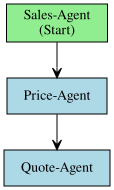

In [24]:
# 在笔记本中内联显示导出的工作流 SVG

from IPython.display import SVG, display, HTML
import os

print(f'尝试显示位于: {svg_file} 的 SVG 文件')

if svg_file and os.path.exists(svg_file):
    try:
        # 首选：直接 SVG 渲染
        display(SVG(filename=svg_file))
    except Exception as e:
        print(f'⚠️ 直接 SVG 渲染失败: {e}。回退到原始 HTML。')
        try:
            with open(svg_file, 'r', encoding='utf-8') as f:
                svg_text = f.read()
            display(HTML(svg_text))
        except Exception as inner:
            print(f'❌ 回退 HTML 渲染也失败: {inner}')
else:
    print('❌ SVG 文件未找到。确保 viz.export(format="svg") 成功运行。')

In [25]:
image_path = '../imgs/home.png'
with open(image_path, 'rb') as image_file:
    image_b64 = base64.b64encode(image_file.read()).decode()
image_uri = f'data:image/png;base64,{image_b64}'


In [26]:
message = ChatMessage(
        role=Role.USER,
        contents=[
            TextContent(text='请根据图片找到相关家具并为每件家具给出相应价格'),
            DataContent(uri=image_uri, media_type='image/png')
        ]
)

NameError: name 'TextContent' is not defined

In [ ]:
result=''
async for event in workflow.run_stream(message):
    if isinstance(event, DatabaseEvent):
        print(f'{event}')
    if isinstance(event, WorkflowEvent):
        result += str(event.data)

In [ ]:
result.replace('None', '')